In [2]:
# Cell 1: Imports and Setup
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from realta.config import SimulationConfig
from realta.simulation.cluster import ClusterSimulation

# Styling to match MNRAS figures
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 12,
        "axes.labelsize": 14,
        "legend.fontsize": 10,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "figure.autolayout": True,
    }
)

In [5]:
# Cell 2: Run Baseline Simulation (f_sur = 1, Kroupa IMF)
config = SimulationConfig(
    ntot=100_000,
    imf_type=2,  # Kroupa IMF
    tmax=100.0,  # 100 Myr
    dt=0.5,  # 0.5 Myr steps
    lxmin=33.0,  # log10(erg/s) -- 1e35 erg/s, NOT the linear value
    lxmax=38.0,  # log10(erg/s) -- 1e38 erg/s, matches paper's L_X^peak
    fsur=1,  # Fig. 1 baseline: every bound binary becomes an HMXB
)

sim = ClusterSimulation(config)
results = sim.run(output_dir="paper_output")

time = np.array([r["time"] for r in results])
lumx_tot = np.array([r["lumx_tot"] for r in results])  # now in erg/s
nphot_tot = np.array([r["nphot_tot"] for r in results])  # now in s^-1

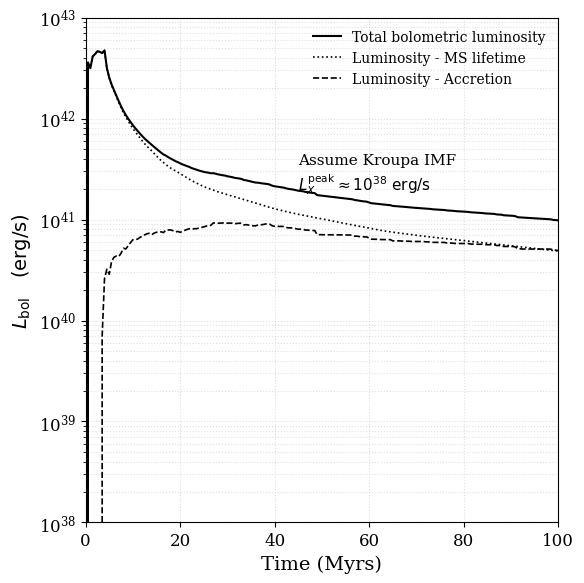

In [6]:
# Cell 3: Figure 1 - Total Bolometric Luminosity (Power et al. 2009, Fig. 1)
# MS bolometric luminosity from FSPS (Kroupa IMF, instantaneous burst)
# -- see src/realta/io/tables.py:MSLuminosityTable and
# notebooks_helper/generate_ms_luminosity_table.py for provenance.
#
# The tabulated FSPS values are baked to a fixed fiducial 1e6 Msun
# cluster; get_lbol() rescales linearly to THIS run's actual total
# formed stellar mass (sim.population.total_mass_msun), which is
# smaller than 1e6 Msun for this config's ntot/mmin/mmax. Without this
# rescaling the MS curve is far too bright relative to lumx_tot and the
# MS/HMXB crossover appears many times later than in the paper.
from realta.io.tables import MSLuminosityTable

total_mass_msun = sim.population.total_mass_msun
print(f"Total mass formed: {total_mass_msun:.3e} Msun")

ms_table = MSLuminosityTable(imetal=config.imetal)
ms_lum_bol = np.array([ms_table.get_lbol(t, total_mass_msun) for t in time])

# Total bolometric = MS + HMXB X-ray accretion (both now in erg/s)
total_lbol = ms_lum_bol + lumx_tot

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(time, total_lbol, "k-", linewidth=1.5, label="Total bolometric luminosity")
ax.plot(time, ms_lum_bol, "k:", linewidth=1.2, label="Luminosity - MS lifetime")
ax.plot(time, lumx_tot, "k--", linewidth=1.2, label="Luminosity - Accretion")

ax.set_yscale("log")
ax.set_xlim(0, 100)
ax.set_ylim(1e38, 1e43)

ax.set_xlabel("Time (Myrs)")
ax.set_ylabel(r"$L_{\mathrm{bol}}\quad (\mathrm{erg/s})$")

ax.text(
    45,
    2e41,
    "Assume Kroupa IMF\n$L_X^{\\mathrm{peak}} \\approx 10^{38}\\mathrm{\\ erg/s}$",
    fontsize=11,
)
ax.legend(loc="upper right", frameon=False)
ax.grid(True, which="both", linestyle=":", alpha=0.4)

plt.show()

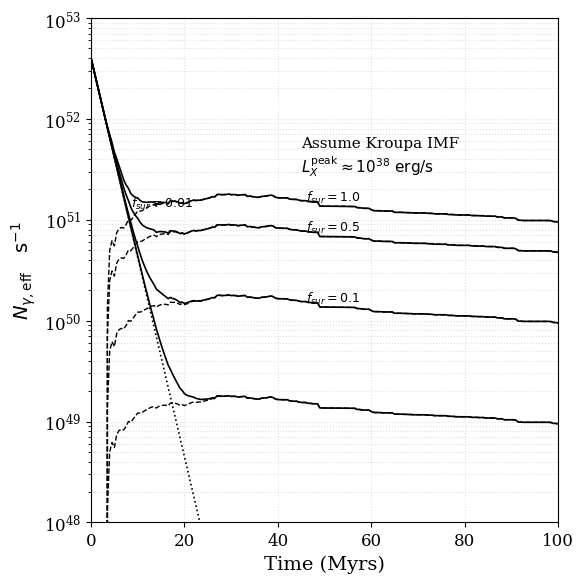

In [7]:
# Cell 4: Figure 2 - Hydrogen Ionizing Photon Rate vs. f_sur (Power et al. 2009, Fig. 2)
# Photons from MS (STARBURST99 baseline ~ 4e52 s^-1 peak)
n_gamma_ms = 4.0e52 * np.exp(-time / 2.2)

fsur_values = [1.0, 0.5, 0.1, 0.01]
fig, ax = plt.subplots(figsize=(6, 6))

# Plot MS contribution
ax.plot(time, n_gamma_ms, "k:", linewidth=1.2, label="Ionising photons - MS lifetime")

for fsur in fsur_values:
    # Scale HMXB accretion photon rate by survival fraction f_sur
    n_gamma_hmxb = nphot_tot * fsur
    n_gamma_tot = n_gamma_ms + n_gamma_hmxb

    ax.plot(time, n_gamma_tot, "k-", linewidth=1.2)
    ax.plot(time, n_gamma_hmxb, "k--", linewidth=1.0)

    # Label curves near t = 45 Myr
    idx_label = np.searchsorted(time, 45.0)
    if fsur > 0.01:
        ax.text(
            time[idx_label] + 1,
            n_gamma_tot[idx_label],
            f"$f_{{sur}}={fsur}$",
            fontsize=9,
        )
    else:
        ax.text(time[15] + 1, n_gamma_tot[15], f"$f_{{sur}}={fsur}$", fontsize=9)

ax.set_yscale("log")
ax.set_xlim(0, 100)
ax.set_ylim(1e48, 1e53)

ax.set_xlabel("Time (Myrs)")
ax.set_ylabel(r"$N_{\gamma,\mathrm{eff}}\quad \mathrm{s}^{-1}$")

ax.text(
    45,
    3e51,
    "Assume Kroupa IMF\n$L_X^{\\mathrm{peak}} \\approx 10^{38}\\mathrm{\\ erg/s}$",
    fontsize=11,
)
ax.grid(True, which="both", linestyle=":", alpha=0.4)

plt.show()

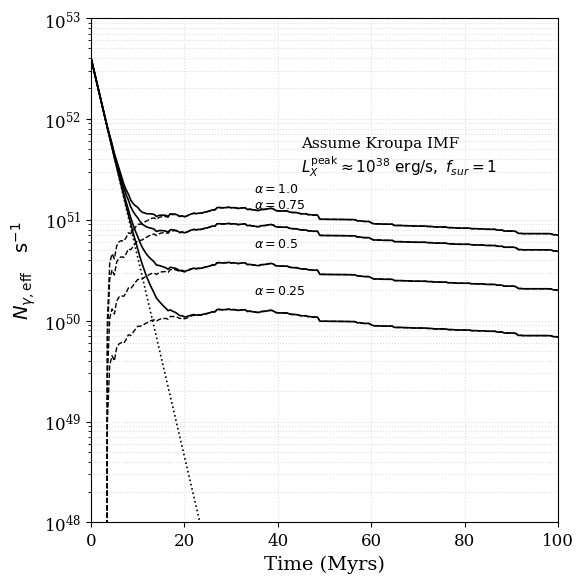

In [8]:
# Cell 5: Figure 3 - Spectral Hardness Dependence alpha (Power et al. 2009, Fig. 3)
# Spectral index alpha controls fraction of soft vs. hard X-ray photons that effectively ionize H I
def calculate_ngamma_alpha(lum_x, alpha, e_min=0.1, e_max=1.0e5, e_lim=1000.0):
    """Calculates effective ionizing photon rate for spectral power law F(E) ~ E^-alpha."""
    if alpha == 1.0:
        norm = lum_x / np.log(e_max / e_min)
        # N_gamma,eff = integral_13.6eV^E_lim (F(E)/13.6eV) dE
        ngamma = (norm / 13.6) * np.log(e_lim / 13.6) * 6.242e11  # erg to eV
    else:
        norm = lum_x * (1.0 - alpha) / (e_max ** (1.0 - alpha) - e_min ** (1.0 - alpha))
        ngamma = (
            (norm / (13.6 * (1.0 - alpha)))
            * (e_lim ** (1.0 - alpha) - 13.6 ** (1.0 - alpha))
            * 6.242e11
        )
    return np.maximum(ngamma, 1.0e35)


alphas = [1.0, 0.75, 0.5, 0.25]
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(time, n_gamma_ms, "k:", linewidth=1.2, label="Ionising photons - MS lifetime")

for alpha in alphas:
    n_gamma_hmxb_alpha = calculate_ngamma_alpha(lumx_tot, alpha)
    n_gamma_tot_alpha = n_gamma_ms + n_gamma_hmxb_alpha

    ax.plot(time, n_gamma_tot_alpha, "k-", linewidth=1.2)
    ax.plot(time, n_gamma_hmxb_alpha, "k--", linewidth=1.0)

    idx_label = np.searchsorted(time, 35.0)
    ax.text(
        time[idx_label],
        n_gamma_tot_alpha[idx_label] * 1.5,
        f"$\\alpha={alpha}$",
        fontsize=9,
    )

ax.set_yscale("log")
ax.set_xlim(0, 100)
ax.set_ylim(1e48, 1e53)

ax.set_xlabel("Time (Myrs)")
ax.set_ylabel(r"$N_{\gamma,\mathrm{eff}}\quad \mathrm{s}^{-1}$")

ax.text(
    45,
    3e51,
    "Assume Kroupa IMF\n$L_X^{\\mathrm{peak}} \\approx 10^{38}\\mathrm{\\ erg/s},\\ f_{sur}=1$",
    fontsize=11,
)
ax.grid(True, which="both", linestyle=":", alpha=0.4)

plt.show()